# Mackenzie dyke swarm ca. 1267 Ma paleomagnetic pole

## Geologic context

The Mackenzie dyke swarm is the giant ca. 1267 Ma radiating mafic dyke swarm of the Canadian Shield, with associated sills, Coppermine River basalts, and the Muskox intrusion. A U-Pb baddeleyite age of 1267 +/- 2 Ma (LeCheminant & Heaman, 1989) dates the swarm.

This notebook now loads the study-specific MagIC files individually, combines the Mackenzie-relevant rows here, and recalculates the pole from the compiled VGPs. Korok-only rows from Fahrig (1986) are retained in the source contribution but excluded from the Mackenzie mean.

In [1]:
import math
from pathlib import Path

import pandas as pd
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Study-Specific Data

Each source is loaded from its own MagIC `sites.txt` file in `../data/1267_Mackenzie/`. Rows flagged `result_quality='b'` are retained only for source auditing or field-test context, not for the recalculated pole.

In [2]:
DATA = Path('../data/1267_Mackenzie')
STUDY_FILES = {
    'Fahrig & Jones 1969': DATA / 'Fahrig1969_sites.txt',
    'Robertson 1969': DATA / 'Robertson1969_sites.txt',
    'Irving et al. 1972': DATA / 'Irving1972_sites.txt',
    'Park 1974': DATA / 'Park1974_sites.txt',
    'Fahrig 1986': DATA / 'Fahrig1986_sites.txt',
}

study_sites = {}
for study, path in STUDY_FILES.items():
    sites_geo, _ = pt.load_magic_sites(path, drop_bad=False)
    sites_geo = sites_geo.copy()
    sites_geo['study'] = study
    study_sites[study] = sites_geo

source_counts = []
for study, df in study_sites.items():
    good = df[df['result_quality'] != 'b']
    source_counts.append({
        'study': study,
        'rows_total': len(df),
        'rows_good': len(good),
        'dir_n_samples_sum_good': int(pd.to_numeric(good['dir_n_samples'], errors='coerce').sum()),
        'locations': '; '.join(sorted(good['location'].dropna().unique())),
    })
pd.DataFrame(source_counts)

,study,rows_total,rows_good,dir_n_samples_sum_good,locations
0,Fahrig & Jones 1969,15,14,63,Mackenzie igneous events
1,Robertson 1969,5,5,56,Muskox Intrusion and associated dykes and lavas
2,Irving et al. 1972,13,10,49,Mackenzie diabase
3,Park 1974,12,12,89,Park 1974 Mackenzie diabases
4,Fahrig 1986,4,4,21,Korok sheets and dykes; Possible Mackenzie dyk...


## Mackenzie Combination

The recalculation starts from the Mackenzie-relevant VGP rows in the study-specific files and then applies a minimum `dir_n_samples >= 3` screen. That keeps the 3- and 4-sample sites that were discarded by the older Buchan & Halls `n >= 5` cutoff, but removes two rows with only two statistical units.

- Fahrig & Jones (1969): 14 accepted Mackenzie igneous-event sites; anomalous site 11 excluded.
- Irving et al. (1972): 10 accepted Mackenzie diabase sites; baked-contact rows excluded from the mean and retained as the field test.
- Park (1974): Mackenzie present-work rows compiled from Table 1/2; the two-unit P74-86C row is excluded by the `n >= 3` screen.
- Fahrig (1986): only FA6709, the possible Mackenzie dyke southeast of Ungava Bay; the 1350-1400 Ma Korok rows are excluded.
- Robertson (1969): published major-unit/zone means for the Muskox/Coppermine/Mackenzie igneous-event result; the two-unit upper-border-zone row is excluded by the `n >= 3` screen. These are unit/zone rows, not a full 143-site transcription.

For comparison, the notebook also computes a unit-weight mean of the five published study/substudy poles, which is the closest analogue to the Evans/Buchan grand-mean style.

In [3]:
def mackenzie_rows_from_study(study, df):
    good = df[df['result_quality'] != 'b'].copy()
    if study == 'Fahrig 1986':
        good = good[good['location'].str.contains('Possible Mackenzie', na=False)].copy()
    return good

mackenzie_parts = [mackenzie_rows_from_study(study, df) for study, df in study_sites.items()]
mackenzie_compiled = pd.concat(mackenzie_parts, ignore_index=True)

n_numeric = pd.to_numeric(mackenzie_compiled['dir_n_samples'], errors='coerce')
mackenzie_sites = mackenzie_compiled[n_numeric >= 3].reset_index(drop=True)
excluded_low_n = mackenzie_compiled[n_numeric < 3][['study', 'site', 'dir_n_samples', 'location']]

study_lat, study_lon = 65.0, 250.0
vgp_block, pole_mean = pt.compute_mean_pole(mackenzie_sites, unify_polarity=True)
dir_block, dir_mean = pt.compute_mean_direction_from_vgps(mackenzie_sites, study_lon, study_lat, unify_polarity=True)

B = int(pole_mean['n'])
N_stat = int(pd.to_numeric(mackenzie_sites['dir_n_samples'], errors='coerce').sum())
print(f'Adopted combined Mackenzie pole (dir_n_samples >= 3): {pole_mean["inc"]:.1f} N / {pole_mean["dec"]:.1f} E, A95 {pole_mean["alpha95"]:.1f}, K {pole_mean["k"]:.1f}, B {B}, tabulated N {N_stat}')
print('Evans/Buchan reported grand mean: 4.0 N / 190.0 E, A95 5.0')
print()
print('Rows excluded by the n >= 3 screen:')
display(excluded_low_n)
mackenzie_sites.groupby('study').agg(B=('site', 'count'), N=('dir_n_samples', 'sum'))

Adopted combined Mackenzie pole (dir_n_samples >= 3): 2.6 N / 189.5 E, A95 2.8, K 65.0, B 40, tabulated N 259
Evans/Buchan reported grand mean: 4.0 N / 190.0 E, A95 5.0

Rows excluded by the n >= 3 screen:


,study,site,dir_n_samples,location
14,Robertson 1969,R69-upper-border-zone,2,Muskox Intrusion and associated dykes and lavas
38,Park 1974,P74-86C,2,Park 1974 Mackenzie diabases


,B,N
study,,
Fahrig & Jones 1969,14,63
Fahrig 1986,1,6
Irving et al. 1972,10,49
Park 1974,11,87
Robertson 1969,4,54


In [4]:
def angular_separation(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    return math.degrees(math.acos(
        max(-1, min(1, math.sin(lat1) * math.sin(lat2) +
                    math.cos(lat1) * math.cos(lat2) * math.cos(lon1 - lon2)))
    ))

evans_pole = {'inc': 4.0, 'dec': 190.0, 'alpha95': 5.0, 'n': 5}
sep = angular_separation(pole_mean['inc'], pole_mean['dec'], evans_pole['inc'], evans_pole['dec'])
print(f'Angular separation from Evans/Buchan pole: {sep:.1f} degrees')
print(f'Combined A95 + Evans A95 = {pole_mean["alpha95"] + evans_pole["alpha95"]:.1f} degrees')
print('Conclusion: the recalculated pole overlaps the Evans/Buchan pole, but is not numerically identical and has a smaller A95.')

Angular separation from Evans/Buchan pole: 1.5 degrees
Combined A95 + Evans A95 = 7.8 degrees
Conclusion: the recalculated pole overlaps the Evans/Buchan pole, but is not numerically identical and has a smaller A95.


## Alternative Averaging Checks

In [5]:
def fisher_from_df(df):
    blk = ipmag.make_di_block(df['vgp_lon'].tolist(), df['vgp_lat'].tolist())
    return pmag.fisher_mean(blk)

def loc_pole(stem, row_selector=None):
    locs = pd.read_csv(DATA / f'{stem}_locations.txt', sep='	', skiprows=1)
    if row_selector is not None:
        locs = locs[row_selector(locs)]
    row = locs.iloc[0]
    return {'study': stem, 'vgp_lon': row['pole_lon'], 'vgp_lat': row['pole_lat'], 'A95': row['pole_alpha95']}

variants = []
for name, df in {
    'adopted n>=3 Mackenzie rows': mackenzie_sites,
    'all compiled Mackenzie rows before n>=3 screen': mackenzie_compiled,
    'exclude Robertson 1969 major-unit rows': mackenzie_sites[mackenzie_sites['study'] != 'Robertson 1969'],
    'Robertson contributes Mackenzie-dyke row only': pd.concat([
        mackenzie_sites[mackenzie_sites['study'] != 'Robertson 1969'],
        mackenzie_sites[mackenzie_sites['site'] == 'R69-mackenzie-dykes']
    ], ignore_index=True),
}.items():
    p = fisher_from_df(df)
    variants.append({
        'calculation': name,
        'B': int(p['n']),
        'tabulated_N': int(pd.to_numeric(df['dir_n_samples'], errors='coerce').sum()),
        'PLAT': round(p['inc'], 1),
        'PLON': round(p['dec'], 1),
        'A95': round(p['alpha95'], 1),
        'K': round(p['k'], 1),
    })

study_poles = pd.DataFrame([
    loc_pole('Fahrig1969'),
    loc_pole('Irving1972'),
    loc_pole('Park1974'),
    loc_pole('Robertson1969'),
    loc_pole('Fahrig1986', lambda d: d['location'].str.contains('Possible Mackenzie', na=False)),
])
p_study = fisher_from_df(study_poles)
variants.append({
    'calculation': 'published study/substudy poles as unit weight',
    'B': int(p_study['n']),
    'tabulated_N': '',
    'PLAT': round(p_study['inc'], 1),
    'PLON': round(p_study['dec'], 1),
    'A95': round(p_study['alpha95'], 1),
    'K': round(p_study['k'], 1),
})
variants.append({
    'calculation': 'Evans/Buchan reported grand mean',
    'B': 5,
    'tabulated_N': '',
    'PLAT': 4.0,
    'PLON': 190.0,
    'A95': 5.0,
    'K': '',
})
pd.DataFrame(variants)

,calculation,B,tabulated_N,PLAT,PLON,A95,K
0,adopted n>=3 Mackenzie rows,40,259,2.6,189.5,2.8,65.0
1,all compiled Mackenzie rows before n>=3 screen,42,263,2.6,189.4,2.7,67.1
2,exclude Robertson 1969 major-unit rows,36,205,2.3,189.3,3.0,62.5
3,Robertson contributes Mackenzie-dyke row only,37,226,2.3,189.6,3.0,61.6
4,published study/substudy poles as unit weight,5,,2.8,190.2,4.4,304.4
5,Evans/Buchan reported grand mean,5,,4.0,190.0,5.0,


## VGP Plot

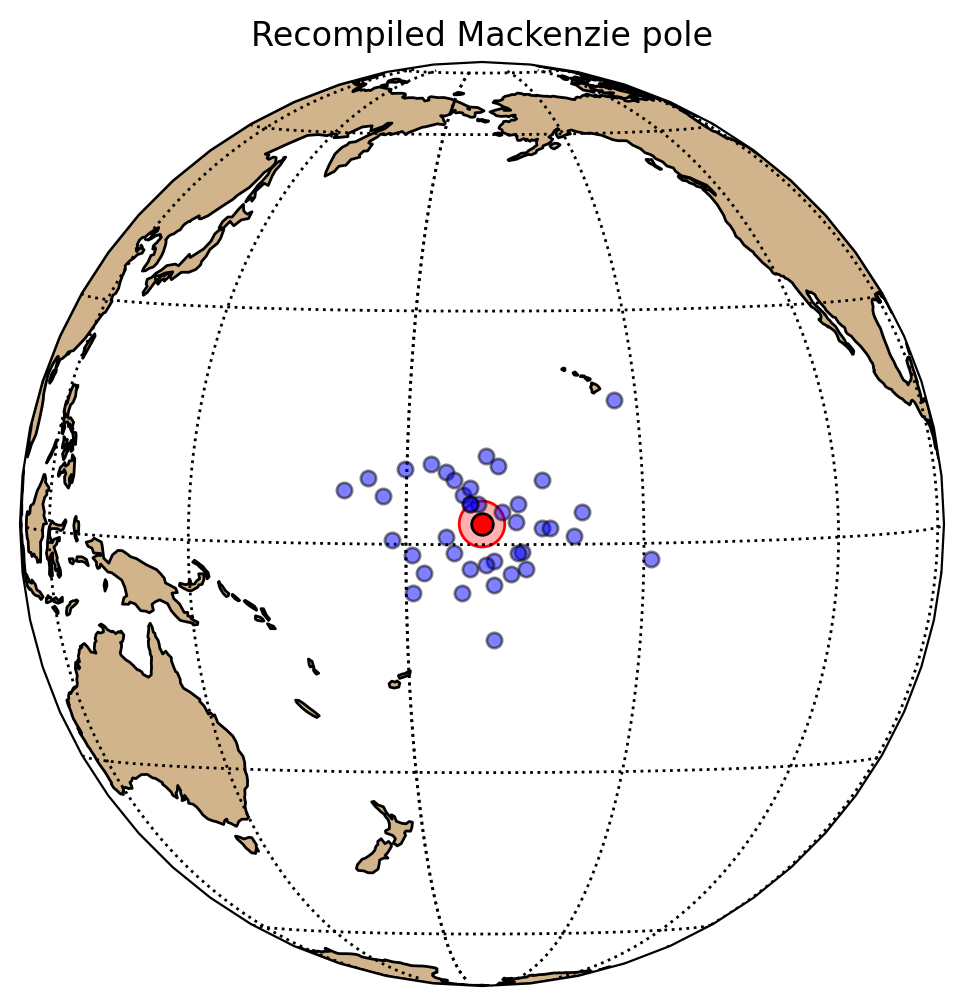

In [6]:
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Recompiled Mackenzie pole')
plt.show()

## Field Test: Irving et al. (1972) Baked Contacts

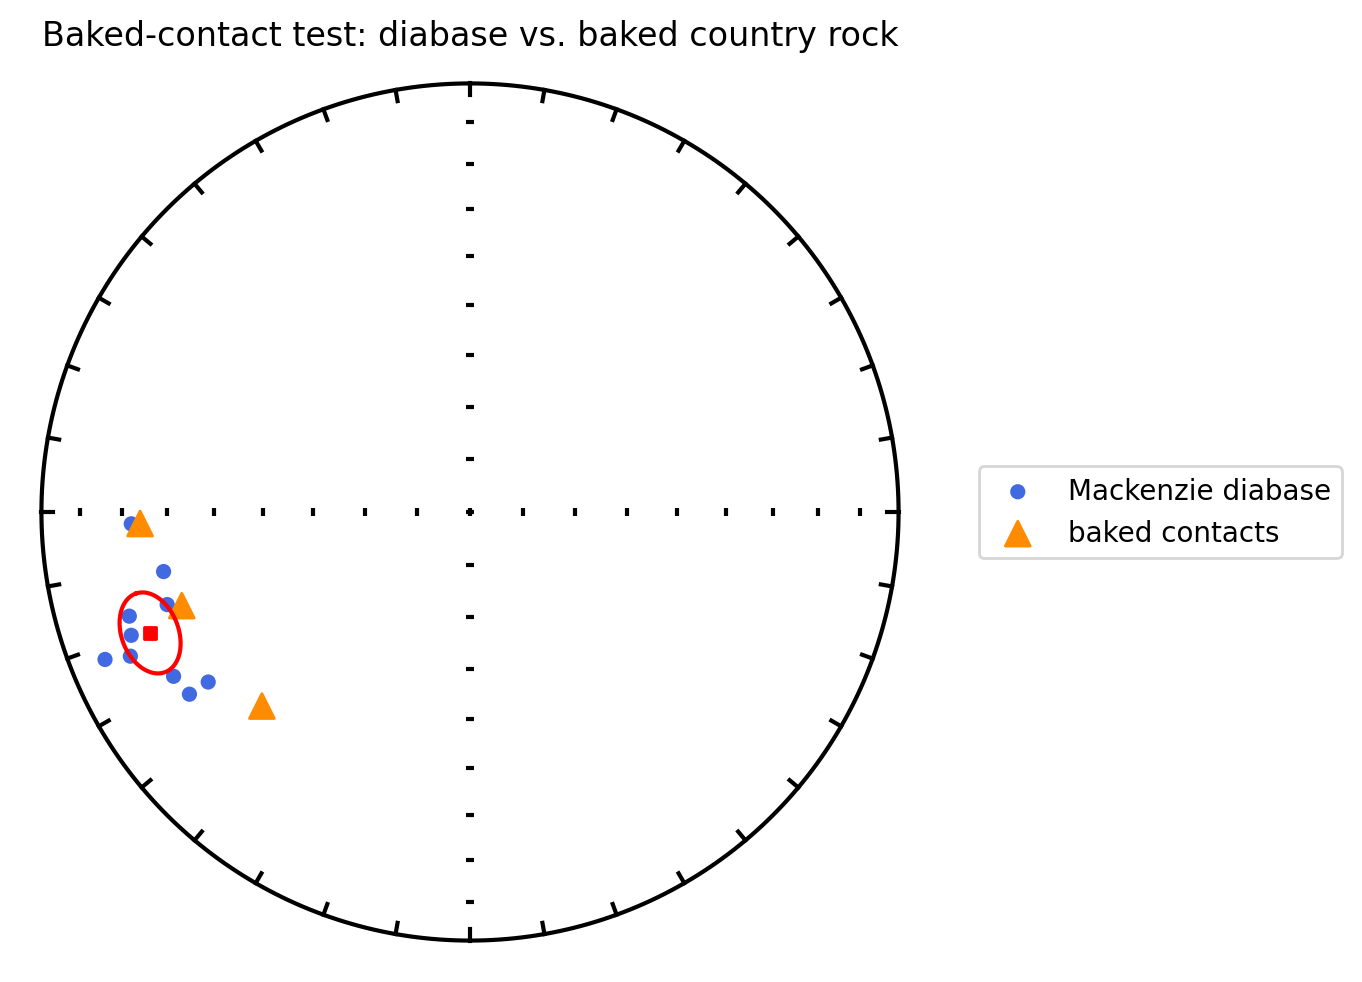

In [7]:
irving_all = study_sites['Irving et al. 1972']
irving_good = irving_all[irving_all['result_quality'] != 'b']
irving_baked = irving_all[irving_all['result_quality'] == 'b']
_, irving_dir_mean = pt.compute_mean_direction(irving_good, unify_polarity=True)

ipmag.plot_net()
ipmag.plot_di(irving_good['dir_dec'].tolist(), irving_good['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Mackenzie diabase')
ipmag.plot_di(irving_baked['dir_dec'].tolist(), irving_baked['dir_inc'].tolist(),
              color='darkorange', marker='^', markersize=80, label='baked contacts')
ipmag.plot_di_mean(irving_dir_mean['dec'], irving_dir_mean['inc'], irving_dir_mean['alpha95'], color='red', marker='s')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Baked-contact test: diabase vs. baked country rock')
plt.show()

## Paleosecular Variation

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 259 samples (>= 25): PASS
        K = 65.0 (10-70): PASS
        B = 40 sites (>= 8): PASS
        min 3 samples/site (>= 3): PASS
        A95 = 2.8 in Deenen envelope [2.7, 8.0]: PASS
  => R2 (from sub-criterion c) = 1
A_95 of 2.8 passes Deenen et al. (2011) criteria of being between 2.7 and 8.0 for this number of sites


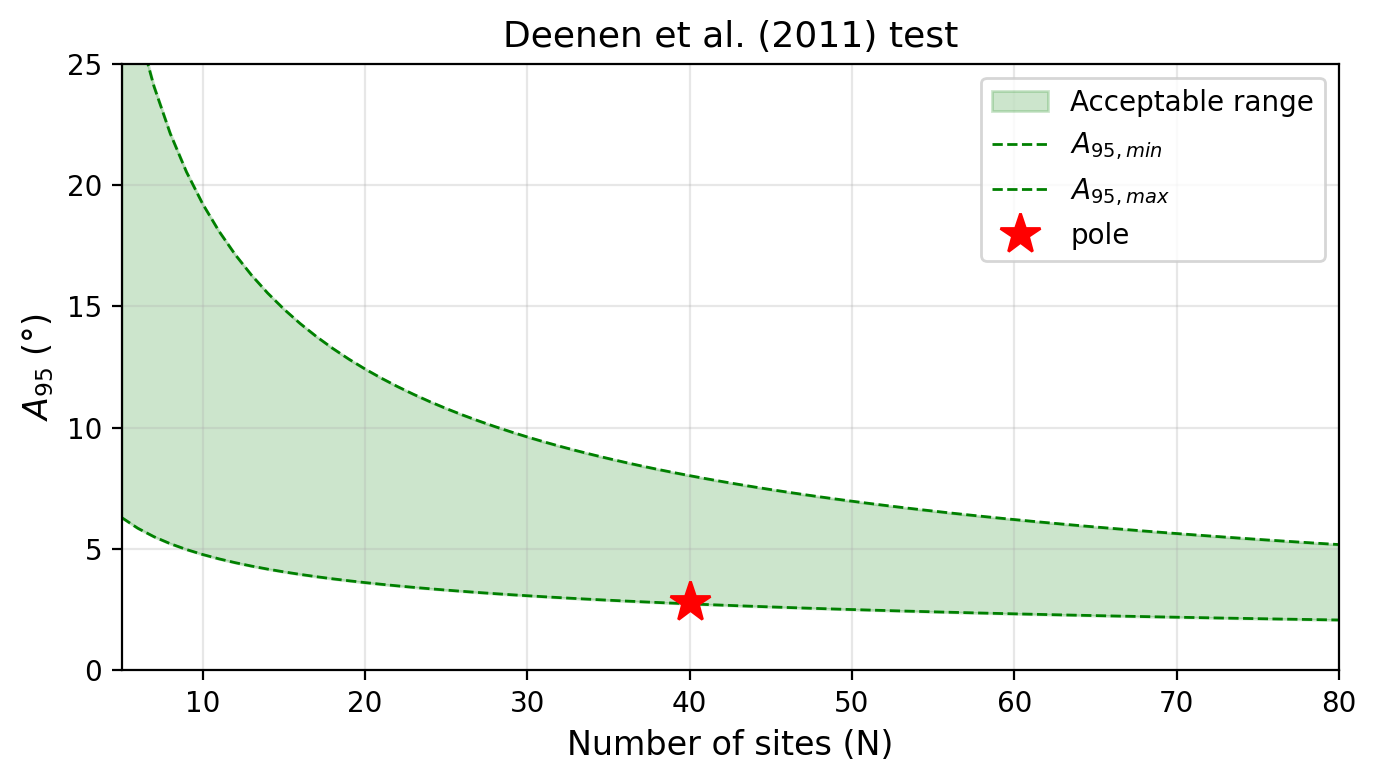

In [8]:
r2 = pt.assess_R2(mackenzie_sites, pole_mean)
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

## The Mackenzie Pole In The Laurentia APWP

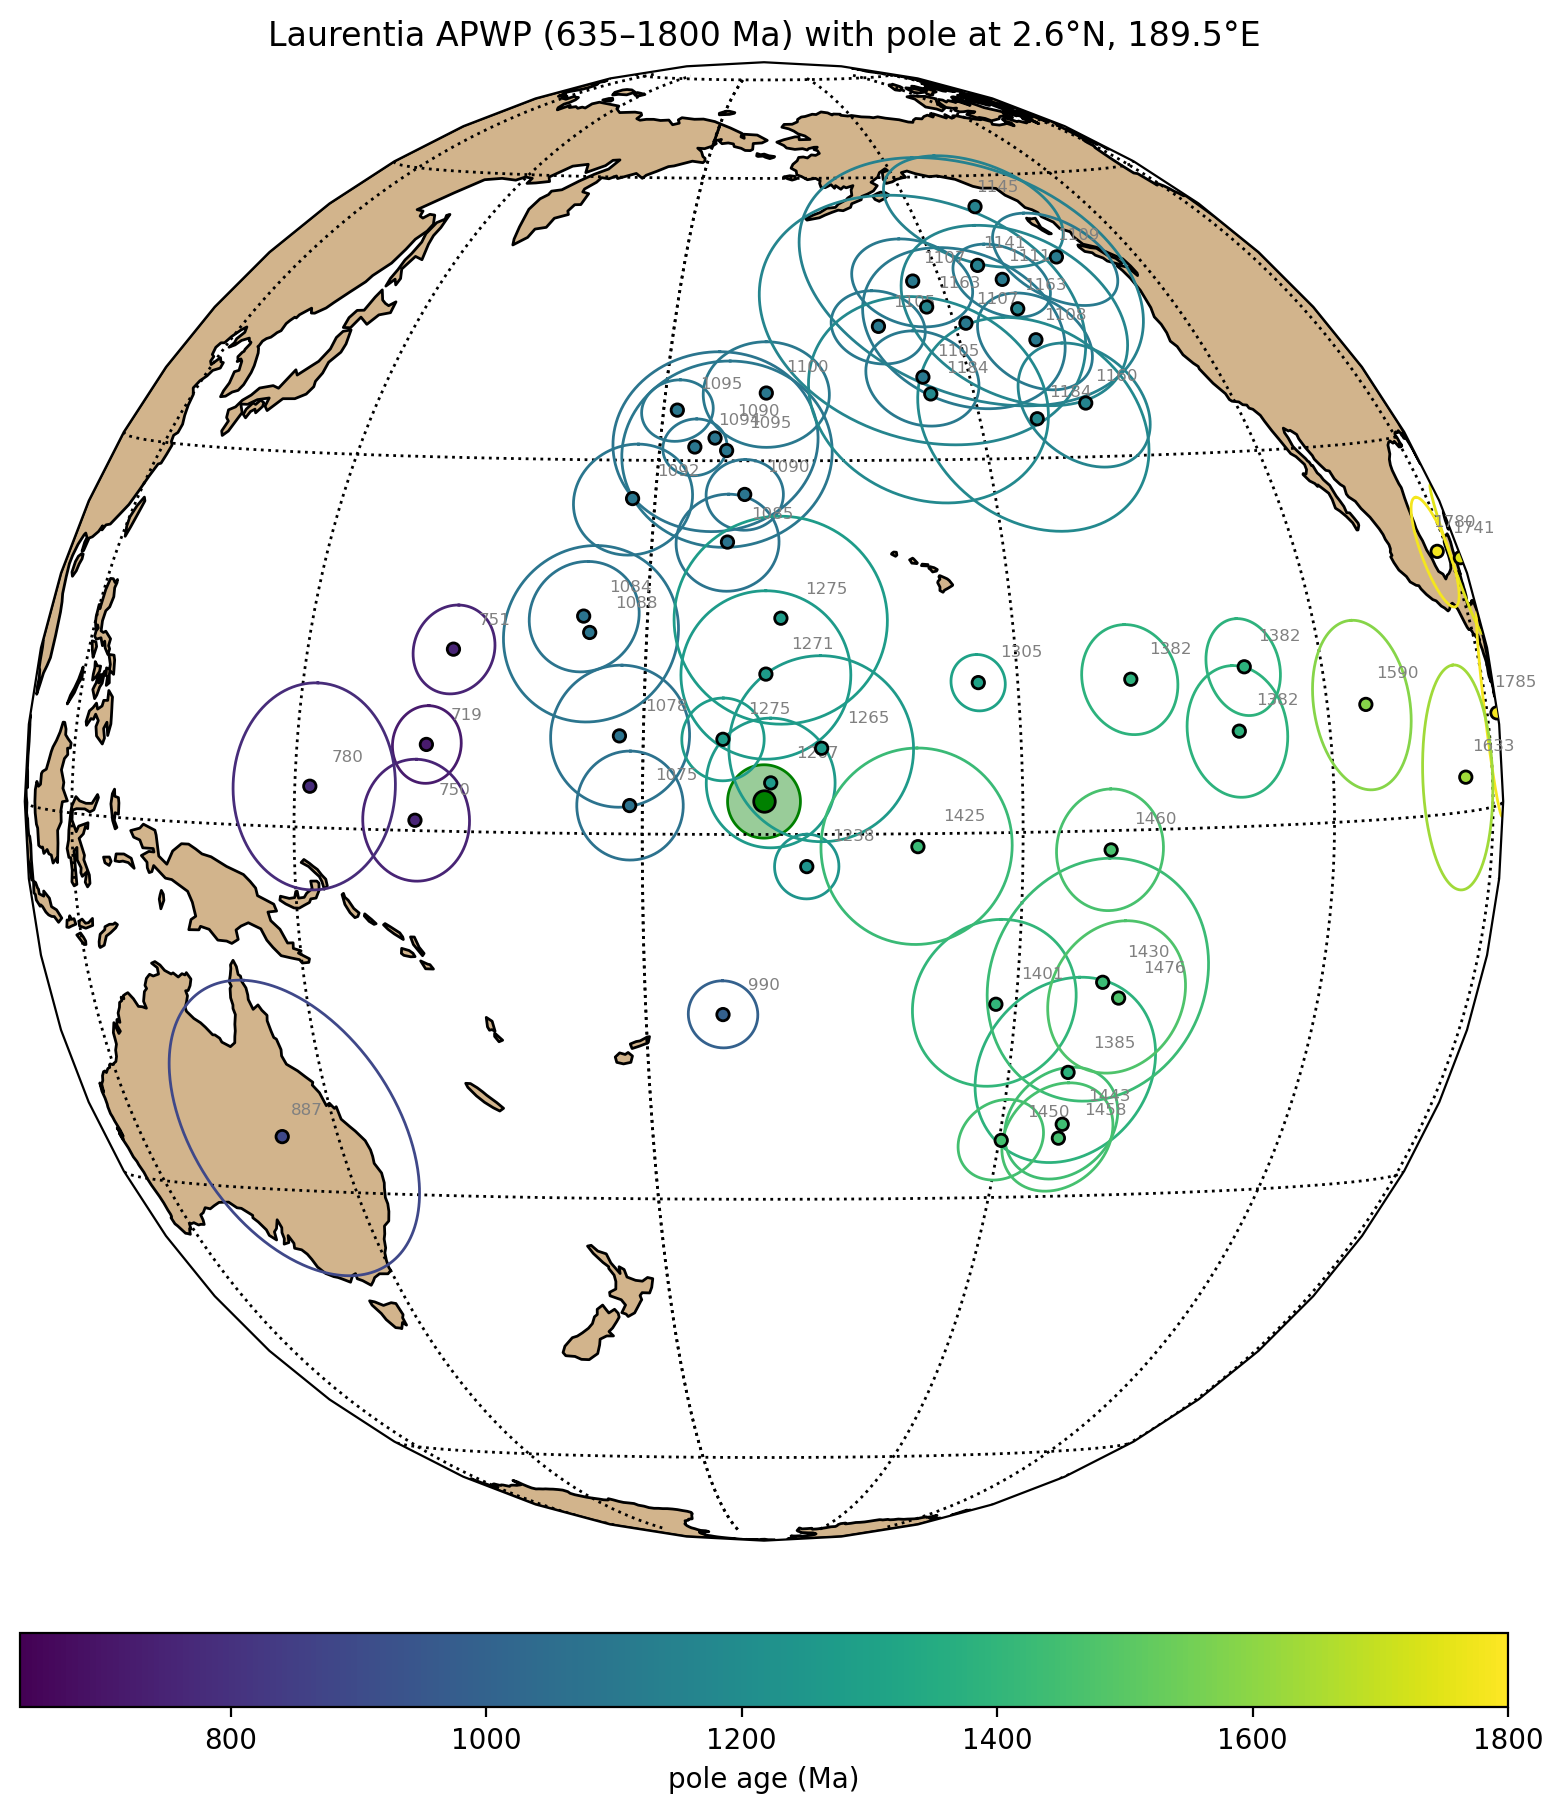

In [9]:
mackenzie_pole = {'inc': pole_mean['inc'], 'dec': pole_mean['dec'], 'alpha95': pole_mean['alpha95'], 'n': pole_mean['n']}
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, mackenzie_pole['inc'], mackenzie_pole['dec'],
                          mackenzie_pole['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=mackenzie_pole['dec'],
                          central_latitude=mackenzie_pole['inc'])
plt.show()

## R7: Comparison With Younger Laurentia Poles

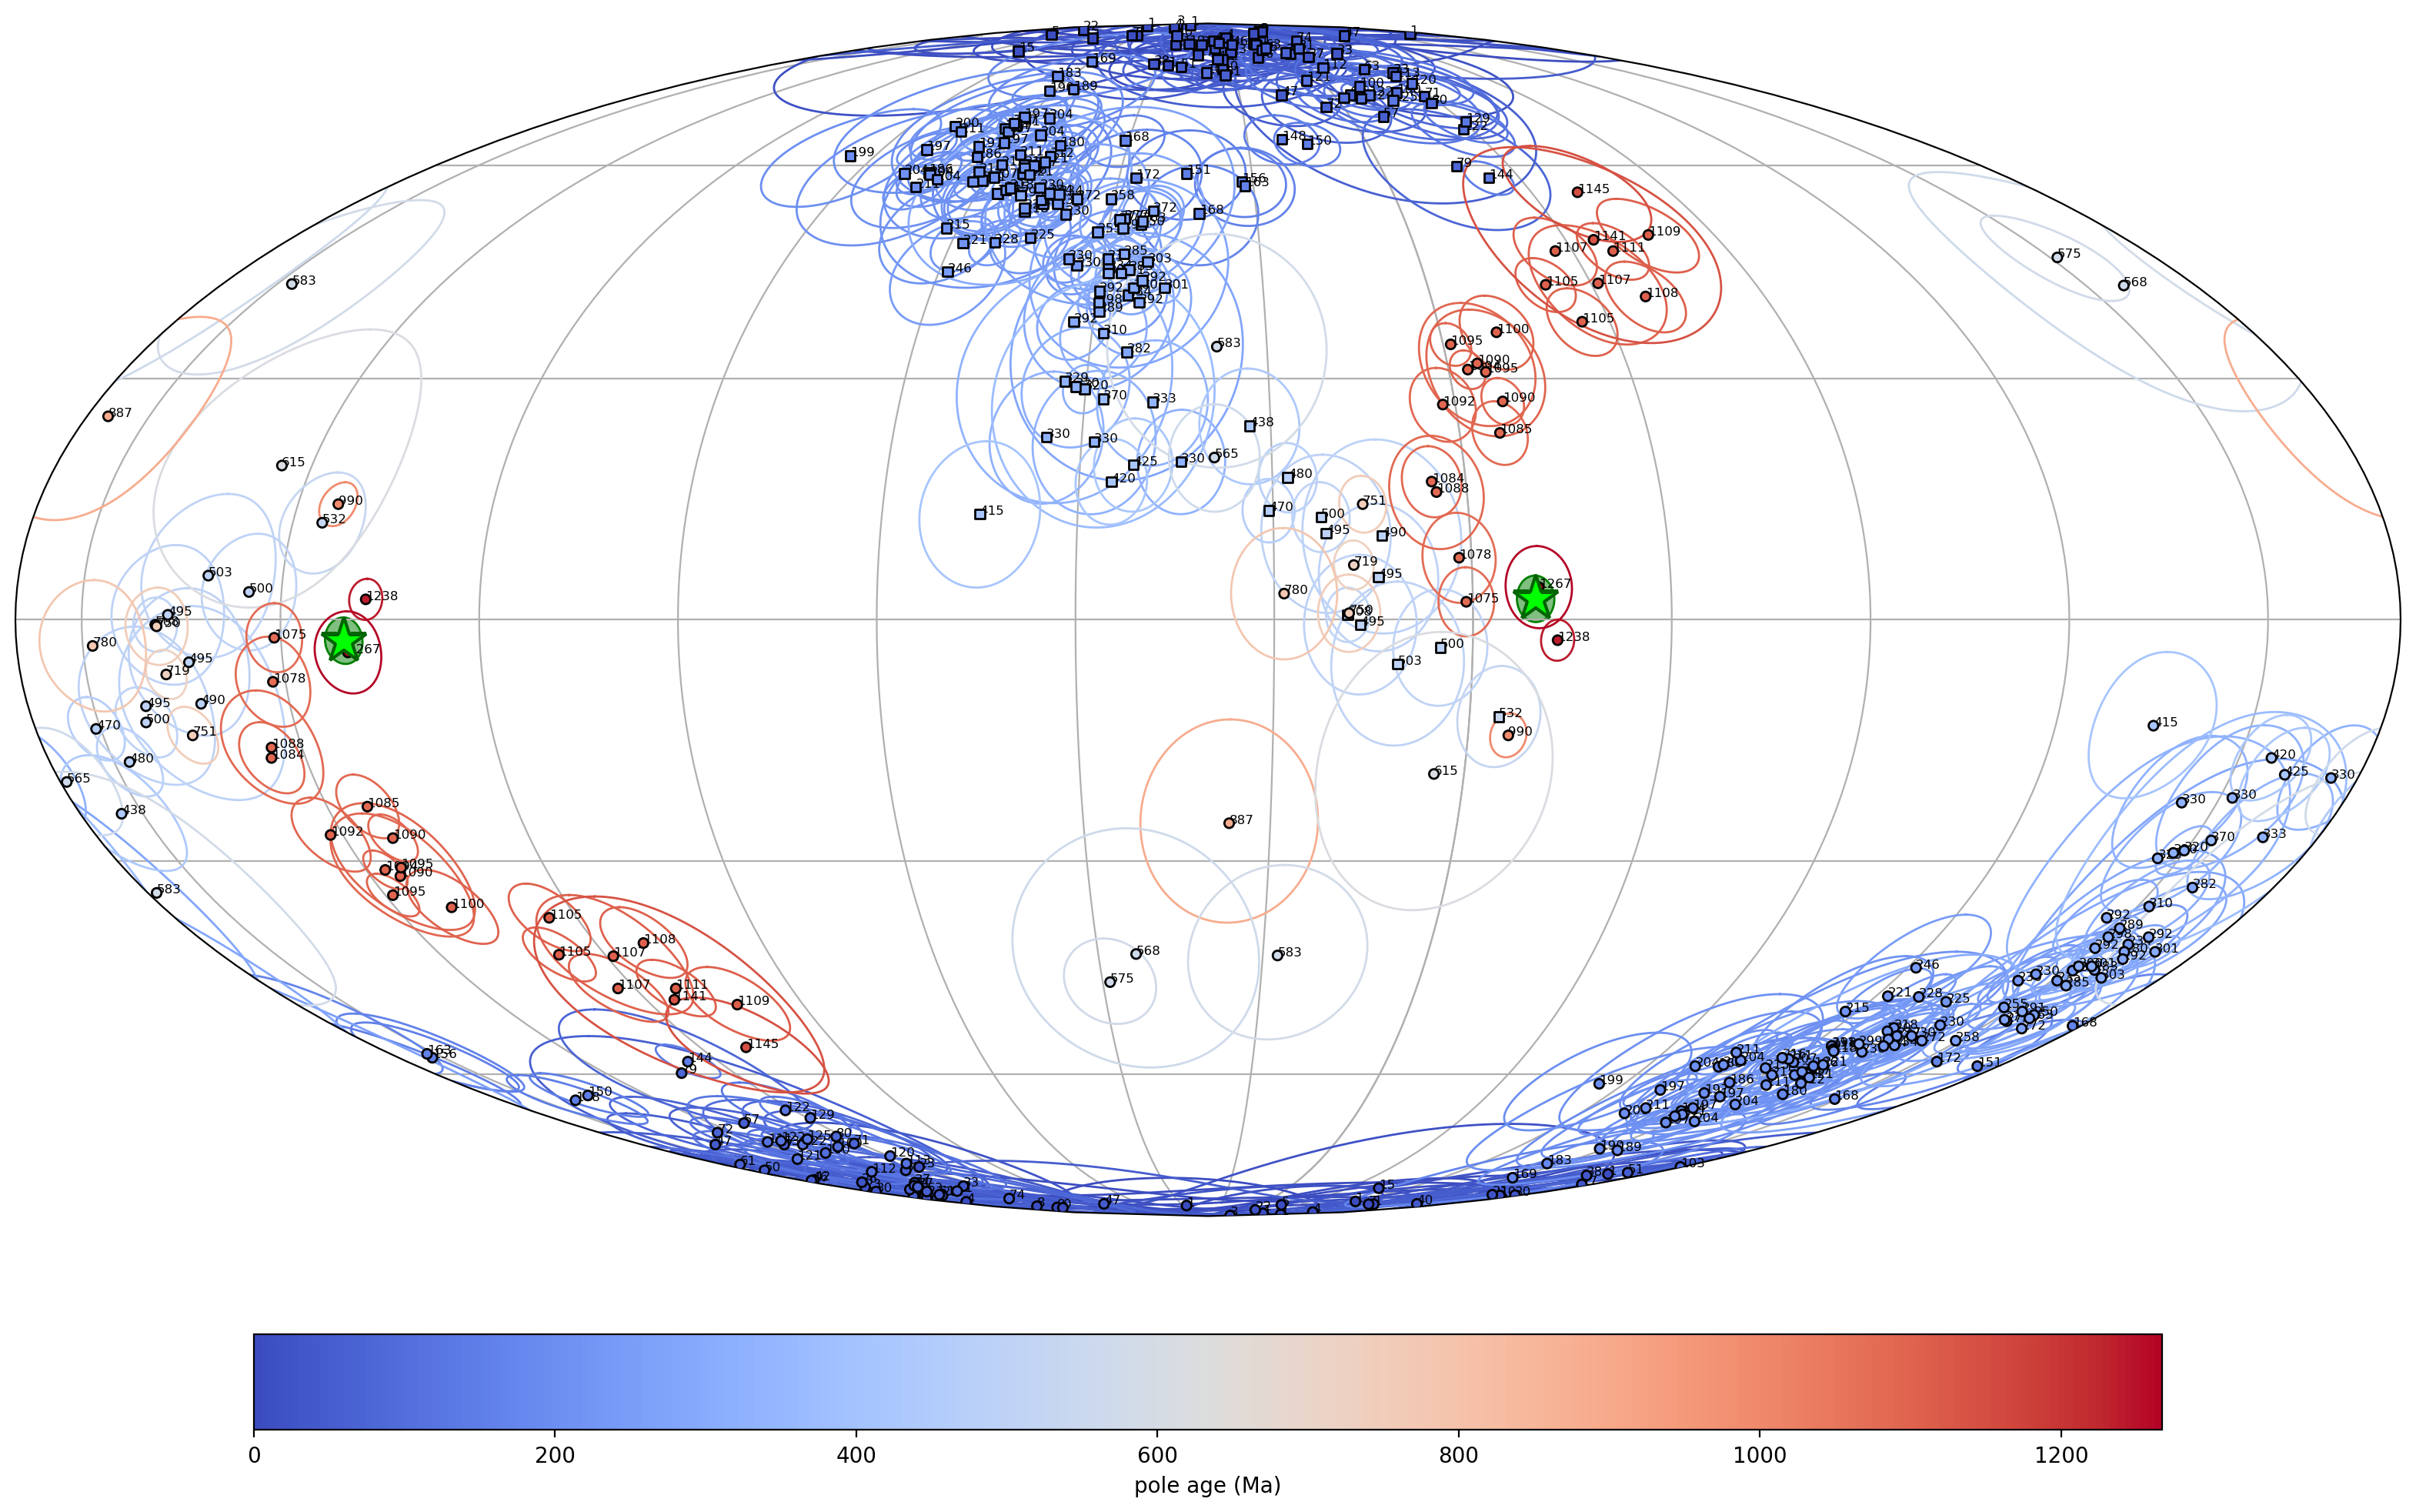

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Mackenzie dykes grand mean', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=mackenzie_pole['inc'], pole_plon=mackenzie_pole['dec'],
                     pole_A95=mackenzie_pole['alpha95'], pole_age=1267)

## R-Score Summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within +/- 15 Ma | **1** | U-Pb baddeleyite 1267 +/- 2 Ma on the Mackenzie swarm (LeCheminant & Heaman, 1989). |
| 2 | Techniques and statistical analysis | **1** | AF and thermal demagnetization are represented across the compiled source studies; B=40 and the VGP distribution passes the quantitative R2/Deenen screen. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite-dominated remanence and stability behavior are described in the source studies. |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test in Irving et al. (1972). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Canadian Shield; vertical dykes / shallow sills / related Mackenzie igneous-event units. |
| 6 | Presence of reversals | **0** | Mackenzie result is effectively single polarity. |
| 7 | No resemblance to younger poles | **1** | A well-resolved Mesoproterozoic key pole, distinct from younger poles. |
| | Total | **6/7** | Grade A |

## Nordic Workshop Summary

In [ ]:
mackenzie_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Mackenzie dykes recompiled',
    sites=mackenzie_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary characteristic remanent magnetization of the Mackenzie igneous event; single dominant polarity',
    tests='C+ (positive baked-contact test in Irving et al. 1972)',
    gpmdb_number='recompiled',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=0, R7=1, Grade='A', Grade_E21='A',
    nominal_age=1267, lomagage=1265, himagage=1269,
    REF_method='U-Pb baddeleyite age 1267 +/- 2 Ma on the Mackenzie dyke swarm (LeCheminant & Heaman, 1989); pole recalculated here from study-specific MagIC files for Fahrig & Jones (1969), Robertson (1969), Irving et al. (1972), Park (1974), and Fahrig (1986).',
    POLE_AUTHORS='Fahrig, W. F.; Jones, D. L.; Robertson, W. A.; Irving, E.; Park, J. K.; McGlynn, J. C.',
    YEAR=2026,
    JOURNAL='Recompiled from published studies',
    VOLUME='',
    VPAGES='',
    TITLE='Mackenzie dyke swarm recompiled from study-specific MagIC contributions',
    COMMENT=(f'Recompiled Mackenzie pole from B={B} accepted site/unit VGP rows after dir_n_samples >= 3 screening and tabulated N={N_stat}: '
             f'{pole_mean["inc"]:.1f}N/{pole_mean["dec"]:.1f}E, A95 {pole_mean["alpha95"]:.1f}, K {pole_mean["k"]:.1f}. '
             'Korok-only Fahrig (1986) rows excluded; FA6709 possible Mackenzie dyke included. Rows with dir_n_samples < 3 excluded. Robertson (1969) contributes major-unit/zone means rather than a full 143-site transcription. '
             'The result overlaps the Evans/Buchan reported grand mean 4N/190E, A95 5, but is not numerically identical and is more tightly constrained.')
)
pt.save_nordic_summary(mackenzie_summary, '1267_Mackenzie')
mackenzie_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Mackenzie dykes recompiled,GPMDB:recompiled,Primary characteristic remanent magnetization ...,C+ (positive baked-contact test in Irving et a...,0,65.0,250.0,40,259,...,1269,U-Pb baddeleyite age 1267 +/- 2 Ma on the Mack...,Mackenzie dykes recompiled,"Fahrig, W. F.; Jones, D. L.; Robertson, W. A.;...",2026,Recompiled from published studies,,,Mackenzie dyke swarm recompiled from study-spe...,Recompiled Mackenzie pole from B=40 accepted s...
